In [13]:
import pandas as pd
import json
import numpy as np
import re
import concurrent.futures
from pathlib import Path
from typing import Any
from collections import Counter
from scipy import stats
import time
from datetime import datetime
from tqdm.auto import tqdm

# =====================================================================
# 1. KONFIGURASI
# =====================================================================
base_dir   = Path("data_spliting")
output_dir = Path("hasil_ekstraksi")
output_dir.mkdir(parents=True, exist_ok=True)

if not base_dir.exists():
    raise FileNotFoundError(f"Folder sumber '{base_dir}' tidak ditemukan!")

LABEL_BENIGN    = 0
LABEL_MALICIOUS = 1
ENCODING_ORDER  = ["utf-8", "utf-16", "cp1252", "latin-1"]

# Threshold seleksi fitur — Cohen (1988) Statistical Power Analysis
# d >= 0.2: "small effect" — batas minimum fitur yang layak
COHENS_D_THRESHOLD = 0.2
P_VALUE_THRESHOLD  = 0.05
MIN_PREVALENSI_PCT = 5.0  # token harus muncul minimal 5% di salah satu kelas

# Semua 19 karakter sintaksis PowerShell — diekstrak semua, filter belakangan
_CHAR_COL = {
    "$": "char_dollar",    "(": "char_lparen",    ")": "char_rparen",
    "[": "char_lbracket",  "]": "char_rbracket",  "{": "char_lbrace",
    "}": "char_rbrace",    ".": "char_dot",        ",": "char_comma",
    "+": "char_plus",      "-": "char_minus",      "*": "char_star",
    "/": "char_slash",     "=": "char_equal",      "!": "char_exclaim",
    "%": "char_percent",   "^": "char_caret",      "&": "char_ampersand",
    "`": "char_backtick",
}

# Semua 27 node AST yang umum di PowerShell — diekstrak semua
ALL_AST_NODES = [
    # 23 node AST dari Fang et al. (2021)
    # "PowerShell Malware Detection Using Abstract Syntax Tree"
    # Seleksi lebih lanjut menggunakan Cohen's d terhadap MPSD
    "VariableExpressionAst",
    "TypeExpressionAst",
    "SubExpressionAst",
    "StringConstantExpressionAst",
    "StatementBlockAst",
    "ScriptBlockExpressionAst",
    "ScriptBlockAst",
    "PipelineAst",
    "ParenExpressionAst",
    "ParameterAst",
    "NamedBlockAst",
    "MemberExpressionAst",
    "IndexExpressionAst",
    "IfStatementAst",
    "ForStatementAst",
    "ExpandableStringExpressionAst",
    "ConvertExpressionAst",
    "CommandParameterAst",
    "CommandExpressionAst",
    "CommandAst",
    "BinaryExpressionAst",
    "AttributeAst",
    "AssignmentStatementAst"
]

# Stop-words PowerShell — token umum yang muncul merata di semua skrip
STOP_TOKENS = {
    'param','function','return','true','false','null','this','that',
    'else','begin','process','endif','foreach','while','switch',
    'default','break','continue','exit','throw','catch','finally',
    'try','class','enum','using','namespace','public','private',
    'static','void','string','int','bool','object','type',
    'write','read','get','set','new','remove','clear','out',
    'format','select','where','sort','group','measure','compare',
    'powershell','windows','system','microsoft','path','name',
    'value','error','warning','verbose','debug','information',
}

# =====================================================================
# 2. FUNGSI UTILITAS
# =====================================================================
def _read_ps1(fp: Path) -> str:
    for enc in ENCODING_ORDER:
        try:
            return fp.read_text(encoding=enc)
        except (UnicodeDecodeError, OSError):
            continue
    return ""

def _load_corpus(folder: Path, label: int) -> list:
    corpus = []
    for f in sorted(folder.glob("*.ps1")):
        c = _read_ps1(f)
        if c.strip():
            corpus.append({"filename": f.name, "content": c, "label": label})
    return corpus

def _cohens_d(arr_a, arr_b):
    pooled = np.sqrt((np.std(arr_a)**2 + np.std(arr_b)**2) / 2 + 1e-9)
    return abs(np.mean(arr_a) - np.mean(arr_b)) / pooled

# =====================================================================
# 3. FASE 1 — DISCOVERY: temukan token dari train_set
#    (HANYA train_set/malicious dan train_set/benign)
#    Data obfuskasi TIDAK dimasukkan:
#    Ref: Guyon & Elisseeff (2003) — seleksi berbasis distribusi asli
# =====================================================================
print("=" * 80)
print(f"FASE 1 — DISCOVERY TOKEN DARI CORPUS TRAIN SET")
print(f"Threshold: Cohen's d >= {COHENS_D_THRESHOLD} | p < {P_VALUE_THRESHOLD}")
print("=" * 80)
t0 = time.time()

mal_corpus = _load_corpus(base_dir / "train_set" / "malicious", LABEL_MALICIOUS)
ben_corpus = _load_corpus(base_dir / "train_set" / "benign",    LABEL_BENIGN)
print(f"  Malicious (train bersih): {len(mal_corpus)} file")
print(f"  Benign    (train bersih): {len(ben_corpus)} file")
print(f"  [INFO] Data obfuskasi tidak disertakan dalam discovery fitur")

# 3a. Ekstrak semua token unik dari corpus
print("\n  Mengekstrak semua token unik dari corpus...")
token_counter_mal = Counter()
token_counter_ben = Counter()

for d in mal_corpus:
    tokens = set(re.findall(r'[a-z][\w\-\.]{3,}', d['content'].lower()))
    token_counter_mal.update(tokens)
for d in ben_corpus:
    tokens = set(re.findall(r'[a-z][\w\-\.]{3,}', d['content'].lower()))
    token_counter_ben.update(tokens)

print(f"  Token unik di malicious: {len(token_counter_mal)}")
print(f"  Token unik di benign   : {len(token_counter_ben)}")

# 3b. Filter: prevalensi >= MIN_PREVALENSI_PCT & bukan stop-word
kandidat = []
n_mal, n_ben = len(mal_corpus), len(ben_corpus)

for tok in set(list(token_counter_mal.keys()) + list(token_counter_ben.keys())):
    if tok in STOP_TOKENS or len(tok) < 4:
        continue
    prev_mal = token_counter_mal.get(tok, 0) / n_mal * 100
    prev_ben = token_counter_ben.get(tok, 0) / n_ben * 100
    if prev_mal >= MIN_PREVALENSI_PCT or prev_ben >= MIN_PREVALENSI_PCT:
        kandidat.append(tok)

print(f"  Kandidat setelah filter prevalensi + stop-word: {len(kandidat)}")

# 3c. Hitung Cohen's d per token (kehadiran biner per dokumen)
print("  Menghitung Cohen's d per token...")
token_selected = []

for tok in tqdm(kandidat, desc="  Cohen's d"):
    arr_mal = np.array([1 if tok in d['content'].lower() else 0 for d in mal_corpus])
    arr_ben = np.array([1 if tok in d['content'].lower() else 0 for d in ben_corpus])
    cd = _cohens_d(arr_mal, arr_ben)
    try:
        _, pval = stats.mannwhitneyu(arr_mal, arr_ben, alternative='two-sided')
    except:
        pval = 1.0
    if cd >= COHENS_D_THRESHOLD and pval < P_VALUE_THRESHOLD:
        token_selected.append({
            'token': tok, 'cohens_d': round(cd, 4), 'p_value': round(pval, 6),
            'prev_mal': round(arr_mal.mean()*100, 1),
            'prev_ben': round(arr_ben.mean()*100, 1),
        })

token_selected.sort(key=lambda x: -x['cohens_d'])
DISCOVERED_KEYWORDS = [t['token'] for t in token_selected]

print(f"\n  TOKEN LEKSIKAL TERPILIH: {len(DISCOVERED_KEYWORDS)}")
print(f"  Top 10:")
for t in token_selected[:10]:
    print(f"    {t['token']:<40} d={t['cohens_d']:.4f}  mal={t['prev_mal']}%  ben={t['prev_ben']}%")

# 3d. Hitung Cohen's d per fitur statistik
print(f"\n  Menghitung Cohen's d fitur statistik...")
stat_selected = []
stat_names_26 = (
    ["script_length","line_count","avg_line_length","max_line_length","has_url_or_ip"]
    + list(_CHAR_COL.values())
    + ["var_count","string_literal_count"]
)

def _all_stat(content):
    lines = content.splitlines()
    feats = {
        "script_length": len(content),
        "line_count": len(lines),
        "avg_line_length": sum(len(l) for l in lines)/max(len(lines),1),
        "max_line_length": max((len(l) for l in lines), default=0),
        "has_url_or_ip": int(bool(re.search(r'https?://|(?:\d{1,3}\.){3}\d{1,3}', content, re.I))),
    }
    for char, col in _CHAR_COL.items():
        feats[col] = content.count(char)
    feats["var_count"] = len(re.findall(r"\$[a-zA-Z_]\w*", content))
    feats["string_literal_count"] = len(re.findall(r"'[^']*'", content)) + len(re.findall(r'"[^"]*"', content))
    return feats

stat_mal = pd.DataFrame([_all_stat(d['content']) for d in mal_corpus])
stat_ben = pd.DataFrame([_all_stat(d['content']) for d in ben_corpus])

for col in stat_names_26:
    cd = _cohens_d(stat_mal[col].values, stat_ben[col].values)
    try:
        _, pval = stats.mannwhitneyu(stat_mal[col].values, stat_ben[col].values, alternative='two-sided')
    except:
        pval = 1.0
    layak = "YA" if cd >= COHENS_D_THRESHOLD and pval < P_VALUE_THRESHOLD else "TIDAK"
    stat_selected.append({
        'fitur': col, 'cohens_d': round(cd, 4), 'p_value': round(pval, 6), 'layak': layak,
        'mean_mal': round(stat_mal[col].mean(), 2), 'mean_ben': round(stat_ben[col].mean(), 2),
    })

stat_selected.sort(key=lambda x: -x['cohens_d'])
STAT_LAYAK = [s['fitur'] for s in stat_selected if s['layak'] == 'YA']

print(f"\n  FITUR STATISTIK — Hasil seleksi (d >= {COHENS_D_THRESHOLD}):")
for s in stat_selected:
    mark = "✓" if s['layak'] == "YA" else " "
    print(f"    {mark} {s['fitur']:<28} d={s['cohens_d']:.4f}  mal={s['mean_mal']:.1f}  ben={s['mean_ben']:.1f}")
print(f"  Layak: {len(STAT_LAYAK)}/{len(stat_selected)}")

# 3e. Simpan hasil discovery token dan statistik
# (Seleksi AST dan filter akhir dilakukan di Cell 3 dari CSV lengkap)
print(f"\n  Menyiapkan struktur data AST...")
ast_selected = []
for node in ALL_AST_NODES:
    ast_selected.append({
        'node_ast': node, 'cohens_d': 0.0, 'p_value': 1.0, 
        'layak': 'TIDAK', 'mean_mal': 0.0, 'mean_ben': 0.0
    })
AST_LAYAK = []

# Simpan hasil discovery token dan statistik
discovery_df = pd.DataFrame(token_selected)
discovery_df.to_csv(output_dir / "discovery_token_leksikal.csv", index=False)
pd.DataFrame(stat_selected).to_csv(output_dir / "discovery_statistik.csv", index=False)
pd.DataFrame(ast_selected).to_csv(output_dir / "discovery_ast.csv", index=False)

print(f"\n  Hasil discovery disimpan ke:")
print(f"    - discovery_token_leksikal.csv ({len(DISCOVERED_KEYWORDS)} token)")
print(f"    - discovery_statistik.csv ({len(stat_selected)} fitur statistik)")
print(f"    - discovery_ast.csv ({len(AST_LAYAK)} dari {len(ALL_AST_NODES)} node layak)")

# =====================================================================
# 4. FASE 2 — EKSTRAKSI: gunakan token yang ditemukan
#    Ekstrak SEMUA fitur (26 stat + discovered tokens + 27 AST)
#    agar CSV berisi segalanya — filter di tahap modeling
# =====================================================================
print(f"\n{'='*80}")
print(f"FASE 2 — EKSTRAKSI FITUR KE CSV")
print(f"{'='*80}")

def _stat_features(script: str) -> dict[str, Any]:
    """Ekstrak SEMUA 26 fitur statistik."""
    lines = script.splitlines()
    feats = {
        "script_length":    len(script),
        "line_count":       len(lines),
        "avg_line_length":  sum(len(l) for l in lines) / max(len(lines), 1),
        "max_line_length":  max((len(l) for l in lines), default=0),
        "has_url_or_ip":    int(bool(re.search(
            r'https?://|(?:\d{1,3}\.){3}\d{1,3}', script, re.I))),
    }
    for char, col in _CHAR_COL.items():
        feats[col] = script.count(char)
    return feats

def _lex_features(script: str) -> dict[str, Any]:
    """Ekstrak fitur leksikal dari token yang DITEMUKAN oleh discovery."""
    feats = {
        "var_count":            len(re.findall(r"\$[a-zA-Z_]\w*", script)),
        "string_literal_count": len(re.findall(r"'[^']*'", script))
                              + len(re.findall(r'"[^"]*"', script)),
    }
    sl = script.lower()
    for tok in DISCOVERED_KEYWORDS:
        col = "tok_" + re.sub(r"[^a-z0-9]", "_", tok)
        feats[col] = sl.count(tok)
    return feats

def create_base_csv(target_folder: Path, output_csv: Path, desc: str):
    all_files = []
    for sub, lbl in [("benign", LABEL_BENIGN), ("malicious", LABEL_MALICIOUS)]:
        p = target_folder / sub
        if p.exists():
            all_files.extend((fp, lbl) for fp in sorted(p.glob("*.ps1")))
    if not all_files:
        return False

    def _process(fp, lbl):
        script = _read_ps1(fp)
        row = {"filename": fp.name, "label": lbl,
               **_stat_features(script), **_lex_features(script)}
        row.update({n: 0 for n in ALL_AST_NODES})
        return row

    records = []
    with concurrent.futures.ThreadPoolExecutor() as ex:
        futs = [ex.submit(_process, fp, lbl) for fp, lbl in all_files]
        for f in tqdm(concurrent.futures.as_completed(futs),
                     total=len(all_files), desc=f"Ekstrak ({desc})"):
            records.append(f.result())

    df = pd.DataFrame(records).fillna(0)
    df.to_csv(output_csv, index=False)
    print(f"  [OK] {output_csv.name} ({len(df)} baris, {len(df.columns)} kolom)")
    return True

t1 = time.time()
for s in ["train_set", "test_set"]:
    folder = base_dir / s
    if folder.exists():
        create_base_csv(folder, output_dir / f"fitur_{s}.csv", s)

for s in ["train_set_obf", "test_set_obf"]:
    folder_obf = base_dir / s
    if folder_obf.exists():
        for td in sorted(f for f in folder_obf.iterdir() if f.is_dir()):
            create_base_csv(td, output_dir / f"fitur_{s}_{td.name}.csv",
                          f"{s}/{td.name}")

durasi_total = (time.time() - t0) / 60
print(f"\nFASE 1+2 SELESAI. Total waktu: {durasi_total:.2f} menit.")
print(f"Fitur per CSV: 26 stat + {len(DISCOVERED_KEYWORDS)} token + 27 AST = {26+len(DISCOVERED_KEYWORDS)+27} kolom")
print(f"(AST masih kosong — diisi di Cell 2 / Tahap berikutnya)")


FASE 1 — DISCOVERY TOKEN DARI CORPUS TRAIN SET
Threshold: Cohen's d >= 0.2 | p < 0.05
  Malicious (train bersih): 1506 file
  Benign    (train bersih): 3443 file
  [INFO] Data obfuskasi tidak disertakan dalam discovery fitur

  Mengekstrak semua token unik dari corpus...
  Token unik di malicious: 180073
  Token unik di benign   : 143458
  Kandidat setelah filter prevalensi + stop-word: 227
  Menghitung Cohen's d per token...


  Cohen's d: 100%|██████████| 227/227 [00:35<00:00,  6.37it/s]



  TOKEN LEKSIKAL TERPILIH: 220
  Top 10:
    intptr                                   d=2.0940  mal=70.9%  ben=1.4%
    kernel32.dll                             d=2.0105  mal=67.7%  ben=0.5%
    virtualalloc                             d=1.9827  mal=66.7%  ben=0.2%
    createthread                             d=1.9723  mal=66.3%  ben=0.2%
    msvcrt.dll                               d=1.9540  mal=65.9%  ben=0.1%
    memset                                   d=1.9519  mal=65.9%  ben=0.2%
    win32functions                           d=1.9405  mal=65.6%  ben=0.2%
    dllimport                                d=1.9370  mal=66.9%  ben=1.0%
    x1000                                    d=1.9360  mal=65.9%  ben=0.4%
    lpaddress                                d=1.9339  mal=65.2%  ben=0.0%

  Menghitung Cohen's d fitur statistik...

  FITUR STATISTIK — Hasil seleksi (d >= 0.2):
    ✓ char_minus                   d=0.3441  mal=30.4  ben=100.8
    ✓ char_lbrace                  d=0.2785  mal=9.1 

Ekstrak (train_set): 100%|██████████| 4949/4949 [00:11<00:00, 421.01it/s] 


  [OK] fitur_train_set.csv (4949 baris, 271 kolom)


...

  [OK] fitur_test_set_obf_String_Concatenation.csv (330 baris, 271 kolom)


Ekstrak (test_set_obf/String_Reordering): 100%|██████████| 330/330 [00:00<00:00, 782.72it/s] 


  [OK] fitur_test_set_obf_String_Reordering.csv (330 baris, 271 kolom)


Ekstrak (test_set_obf/Token_Manipulation): 100%|██████████| 330/330 [00:00<00:00, 957.45it/s] 

  [OK] fitur_test_set_obf_Token_Manipulation.csv (330 baris, 271 kolom)

FASE 1+2 SELESAI. Total waktu: 1.22 menit.
Fitur per CSV: 26 stat + 220 token + 27 AST = 273 kolom
(AST masih kosong — diisi di Cell 2 / Tahap berikutnya)


In [14]:
import subprocess
import json
import pandas as pd
import concurrent.futures
from pathlib import Path
import time
from datetime import datetime
from tqdm.auto import tqdm
import warnings

# =====================================================================
# TAMBAHKAN BARIS INI UNTUK MENUTUP WARNING FRAGMENTASI
# =====================================================================
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
# =====================================================================
# 1. FUNGSI PENAMBALAN AST INLINE (100% KOMPATIBEL & ANTI-HALU)
# =====================================================================
AST_TARGET_NODES = [
    # 23 node AST dari Fang et al. (2021)
    # Fang et al. (2021) — PowerShell Malware Detection Using AST
    "VariableExpressionAst",
    "TypeExpressionAst",
    "SubExpressionAst",
    "StringConstantExpressionAst",
    "StatementBlockAst",
    "ScriptBlockExpressionAst",
    "ScriptBlockAst",
    "PipelineAst",
    "ParenExpressionAst",
    "ParameterAst",
    "NamedBlockAst",
    "MemberExpressionAst",
    "IndexExpressionAst",
    "IfStatementAst",
    "ForStatementAst",
    "ExpandableStringExpressionAst",
    "ConvertExpressionAst",
    "CommandParameterAst",
    "CommandExpressionAst",
    "CommandAst",
    "BinaryExpressionAst",
    "AttributeAst",
    "AssignmentStatementAst"
]
ps_ast_array = ", ".join(f"'{node}'" for node in AST_TARGET_NODES)

def get_ast_inline(file_path: Path) -> dict:
    ps_script = f"""
    $targets = @({ps_ast_array})
    $path = '{file_path.resolve()}'
    try {{
        $tok = $null; $err = $null
        $ast = [System.Management.Automation.Language.Parser]::ParseFile($path, [ref]$tok, [ref]$err)
        
        $counts = @{{}}
        foreach ($t in $targets) {{ $counts[$t] = 0 }}
        
        # MENGGUNAKAN FINDALL MASSAL (Sangat cepat dan kompatibel di semua versi Windows)
        $allNodes = $ast.FindAll({{$true}}, $true)
        
        foreach ($node in $allNodes) {{
            $name = $node.GetType().Name
            if ($counts.ContainsKey($name)) {{
                $counts[$name]++
            }}
        }}

        $counts | ConvertTo-Json -Compress
    }} catch {{
        $fb = @{{}}
        foreach ($t in $targets) {{ $fb[$t] = 0 }}
        $fb | ConvertTo-Json -Compress
    }}
    """
    try:
        res = subprocess.run(
            ["pwsh", "-NoProfile", "-NonInteractive", "-Command", "-"],
            input=ps_script, capture_output=True, text=True, timeout=25
        )
        if res.returncode == 0 and res.stdout.strip():
            raw = json.loads(res.stdout.strip())
            # Mengembalikan 27 fitur AST (semua node, seleksi di tahap modeling)
            return {n: int(raw.get(n, 0)) for n in AST_TARGET_NODES}
    except Exception:
        return None
    return None

def _process_ast_row(args):
    idx, filename, label, target_folder = args
    subfolder = "malicious" if label == 1 else "benign"
    target_file = target_folder / subfolder / filename
    
    ast_result = get_ast_inline(target_file) if target_file.exists() else None
    return idx, ast_result

def append_ast_to_csv(csv_path: Path, target_folder: Path, desc: str):
    if not csv_path.exists():
        return
        
    df = pd.read_csv(csv_path)
    tasks = [(idx, row['filename'], row['label'], target_folder) for idx, row in df.iterrows()]

    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_process_ast_row, task) for task in tasks]
        
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tasks), desc=f"AST Patch ({desc})"):
            idx, ast_result = future.result()
            if ast_result is not None:
                for col_name, value in ast_result.items():
                    df.at[idx, col_name] = value

    df.to_csv(csv_path, index=False)
    print(f"     [OK] Fitur AST Ditambahkan: {csv_path.name}")

# =====================================================================
# 2. EKSEKUSI TAHAP 2 (AST PATCHING)
# =====================================================================
print("="*80)
print(f"▶ MULAI TAHAP 2 (PENAMBALAN FITUR AST): {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
waktu_mulai_ast = time.time()

base_dir = Path("data_spliting")
output_dir = Path("hasil_ekstraksi")
kategori_bersih = ["train_set", "test_set"]
kategori_obfuskasi = ["train_set_obf", "test_set_obf"]

# 2A. Kategori Bersih
for set_name in kategori_bersih:
    folder_target = base_dir / set_name
    if folder_target.exists():
        csv_output = output_dir / f"fitur_{set_name}.csv"
        append_ast_to_csv(csv_output, folder_target, set_name)

# 2B. Kategori Obfuskasi
for set_name in kategori_obfuskasi:
    folder_set_obf = base_dir / set_name
    if folder_set_obf.exists():
        teknik_folders = [f for f in folder_set_obf.iterdir() if f.is_dir()]
        for teknik_dir in teknik_folders:
            teknik_name = teknik_dir.name
            csv_output = output_dir / f"fitur_{set_name}_{teknik_name}.csv"
            append_ast_to_csv(csv_output, teknik_dir, f"{set_name}/{teknik_name}")

durasi_ast = (time.time() - waktu_mulai_ast) / 60
print("="*80)
print(f"⏹ TAHAP 2 SELESAI. Total Waktu AST: {durasi_ast:.2f} Menit.")
print("="*80)

▶ MULAI TAHAP 2 (PENAMBALAN FITUR AST): 2026-07-30 10:31:47


AST Patch (train_set): 100%|██████████| 4949/4949 [25:36<00:00,  3.22it/s]


     [OK] Fitur AST Ditambahkan: fitur_train_set.csv


AST Patch (test_set): 100%|██████████| 1238/1238 [05:51<00:00,  3.52it/s]


     [OK] Fitur AST Ditambahkan: fitur_test_set.csv


...

     [OK] Fitur AST Ditambahkan: fitur_test_set_obf_String_Concatenation.csv


AST Patch (test_set_obf/String_Reordering): 100%|██████████| 330/330 [01:34<00:00,  3.49it/s]


     [OK] Fitur AST Ditambahkan: fitur_test_set_obf_String_Reordering.csv


AST Patch (test_set_obf/Token_Manipulation): 100%|██████████| 330/330 [01:33<00:00,  3.52it/s]

     [OK] Fitur AST Ditambahkan: fitur_test_set_obf_Token_Manipulation.csv
⏹ TAHAP 2 SELESAI. Total Waktu AST: 64.58 Menit.


In [15]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# =====================================================================
# CELL 3 — SELEKSI FITUR + ELIMINASI KE SEMUA CSV
# =====================================================================
output_dir = Path("hasil_ekstraksi")
COHENS_D_THRESHOLD = 0.2
P_VALUE_THRESHOLD  = 0.05

print("=" * 80)
print("CELL 3 — SELEKSI FITUR + ELIMINASI KE SEMUA CSV")
print(f"Threshold: Cohen's d >= {COHENS_D_THRESHOLD} | p-value < {P_VALUE_THRESHOLD}")
print("=" * 80)

# ── TAHAP A: Hitung Cohen's d dari train_set ──────────────────────────
csv_train = output_dir / "fitur_train_set.csv"
if not csv_train.exists():
    raise FileNotFoundError(f"Jalankan Cell 0 dan Cell 1 terlebih dahulu: {csv_train}")

df_train = pd.read_csv(csv_train)
print(f"\nReferensi seleksi: {csv_train.name}")
print(f"  Baris : {len(df_train)} | Kolom: {len(df_train.columns)}")

mal = df_train[df_train["label"] == 1]
ben = df_train[df_train["label"] == 0]
print(f"  Malicious: {len(mal)} | Benign: {len(ben)}")

EXCLUDE = {"filename", "label", "teknik_obfuskasi"}
feature_cols = [c for c in df_train.columns if c not in EXCLUDE]

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2 + 1e-9)
    return abs(np.mean(a) - np.mean(b)) / pooled

print(f"\nMenghitung Cohen's d untuk {len(feature_cols)} fitur...")
results = []
for col in feature_cols:
    a = mal[col].values.astype(float)
    b = ben[col].values.astype(float)
    cd = cohens_d(a, b)
    try:
        _, pval = stats.mannwhitneyu(a, b, alternative="two-sided")
    except:
        pval = 1.0
    kelompok = (
        "AST"      if col.endswith("Ast") else
        "Leksikal" if col.startswith("tok_") else
        "Statistik"
    )
    results.append({
        "fitur":    col,
        "kelompok": kelompok,
        "mean_mal": round(float(np.mean(a)), 4),
        "mean_ben": round(float(np.mean(b)), 4),
        "cohens_d": round(cd, 4),
        "p_value":  round(pval, 6),
        "layak":    "YA" if cd >= COHENS_D_THRESHOLD and pval < P_VALUE_THRESHOLD else "TIDAK",
    })

df_hasil = (pd.DataFrame(results)
              .sort_values("cohens_d", ascending=False)
              .reset_index(drop=True))
df_layak = df_hasil[df_hasil["layak"] == "YA"]
df_tidak = df_hasil[df_hasil["layak"] == "TIDAK"]

# ── Ringkasan seleksi ─────────────────────────────────────────────────
print(f"\n{'='*80}")
print("HASIL SELEKSI (berdasarkan fitur_train_set.csv)")
print(f"{'='*80}")
for kel in ["Statistik", "Leksikal", "AST"]:
    layak = len(df_layak[df_layak["kelompok"] == kel])
    total = len(df_hasil[df_hasil["kelompok"] == kel])
    cd_avg = df_hasil[df_hasil["kelompok"] == kel]["cohens_d"].mean()
    print(f"  {kel:<12}: {layak:>4} / {total:<4} layak  (rata-rata d={cd_avg:.4f})")
print(f"  {'TOTAL':<12}: {len(df_layak):>4} / {len(df_hasil):<4} layak")
print(f"  {'DIHAPUS':<12}: {len(df_tidak):>4} fitur tidak lolos threshold")

# Kolom yang dipertahankan (metadata + fitur layak)
FITUR_FINAL   = df_layak["fitur"].tolist()
KOLOM_SIMPAN  = ["filename", "label"] + FITUR_FINAL

# Simpan hasil seleksi dengan format yang tidak akan terdeteksi proses eliminasi
df_layak.to_csv(output_dir / "fitur_terpilih_dari_data.csv", index=False)
df_tidak.to_csv(output_dir / "fitur_tidak_layak.csv",        index=False)
df_hasil.to_csv(output_dir / "seleksi_semua_fitur.csv",      index=False)

# ── TAHAP B: Terapkan eliminasi ke SEMUA CSV ─────────────────────────
print(f"\n{'='*80}")
print("ELIMINASI FITUR KE SEMUA CSV")
print(f"{'='*80}")
print(f"{'File CSV':<45} {'Sebelum':>10} {'Sesudah':>10} {'Dihapus':>10}")
print("-" * 80)

# PERBAIKAN: Hanya memproses file yang berakhiran set*.csv agar laporan tidak ikut terhapus
semua_csv = sorted(output_dir.glob("fitur_*set*.csv"))

for csv_path in semua_csv:
    df = pd.read_csv(csv_path)
    kolom_sebelum = len(df.columns)

    # Kolom yang ada di file ini (metadata bisa berbeda, misal ada teknik_obfuskasi)
    kolom_ada = [c for c in KOLOM_SIMPAN if c in df.columns]
    
    # Pertahankan juga teknik_obfuskasi jika ada
    if "teknik_obfuskasi" in df.columns:
        kolom_ada = ["filename", "label", "teknik_obfuskasi"] + FITUR_FINAL
        kolom_ada = [c for c in kolom_ada if c in df.columns]

    df_filtered = df[kolom_ada].copy()
    kolom_sesudah = len(df_filtered.columns)
    dihapus = kolom_sebelum - kolom_sesudah

    df_filtered.to_csv(csv_path, index=False)
    print(f"  {csv_path.name:<43} {kolom_sebelum:>10} {kolom_sesudah:>10} {dihapus:>10}")

print(f"\n{'='*80}")
print(f"SELESAI. Semua CSV sudah dieliminasi.")
print(f"  Fitur dipertahankan : {len(FITUR_FINAL)}")
print(f"  Fitur dihapus       : {len(df_tidak)}")
print(f"{'='*80}")

CELL 3 — SELEKSI FITUR + ELIMINASI KE SEMUA CSV
Threshold: Cohen's d >= 0.2 | p-value < 0.05

Referensi seleksi: fitur_train_set.csv
  Baris : 4949 | Kolom: 271
  Malicious: 1506 | Benign: 3443

Menghitung Cohen's d untuk 269 fitur...

HASIL SELEKSI (berdasarkan fitur_train_set.csv)
  Statistik   :    4 / 26   layak  (rata-rata d=0.1033)
  Leksikal    :  111 / 220  layak  (rata-rata d=0.3507)
  AST         :   12 / 23   layak  (rata-rata d=0.2408)
  TOTAL       :  127 / 269  layak
  DIHAPUS     :  142 fitur tidak lolos threshold

ELIMINASI FITUR KE SEMUA CSV
File CSV                                         Sebelum    Sesudah    Dihapus
--------------------------------------------------------------------------------
  fitur_test_set.csv                                 271        129        142
  fitur_test_set_obf_ASCII_Encoding.csv              271        129        142
  fitur_test_set_obf_String_Concatenation.csv        271        129        142
  fitur_test_set_obf_String_Reordering

In [16]:
import pandas as pd
from pathlib import Path

# =====================================================================
# CELL 4 — PENGURUTAN KOLOM CSV (STATISTIK -> LEKSIKAL -> AST)
# =====================================================================
print("="*80)
print("CELL 4 — PENGURUTAN KOLOM CSV (STATISTIK -> LEKSIKAL -> AST)")
print("="*80)

output_dir = Path("hasil_ekstraksi")

# Definisi kolom metadata
metadata_cols = ['filename', 'label', 'teknik_obfuskasi']

# PERBAIKAN: Hanya mengambil file dataset (mengandung kata 'set')
csv_files = list(output_dir.glob("fitur_*set*.csv"))

for csv_path in csv_files:
    # Penanganan aman jika suatu saat mendeteksi file kosong lagi
    try:
        df = pd.read_csv(csv_path)
    except pd.errors.EmptyDataError:
        print(f"  [!] Melewati file kosong: {csv_path.name}")
        continue
        
    cols = df.columns.tolist()
    
    # Identifikasi kelompok fitur berdasarkan nama kolom
    meta = [c for c in cols if c in metadata_cols]
    ast = [c for c in cols if c.endswith("Ast")]
    leksikal = [c for c in cols if c.startswith("tok_")]
    # Statistik adalah sisa kolom yang bukan meta, ast, atau leksikal
    statistik = [c for c in cols if c not in meta + ast + leksikal]
    
    # Gabungkan menjadi urutan baru
    new_order = meta + statistik + leksikal + ast
    
    # Terapkan urutan baru dan timpa file CSV yang lama
    df = df[new_order]
    df.to_csv(csv_path, index=False)
    
    print(f"  [OK] {csv_path.name:<45} -> Diurutkan ({len(new_order)} kolom)")

print(f"\n{'='*80}")
print("SELESAI! Semua CSV telah diurutkan dengan format: Metadata | Statistik | Leksikal | AST")
print(f"{'='*80}")

CELL 4 — PENGURUTAN KOLOM CSV (STATISTIK -> LEKSIKAL -> AST)
  [OK] fitur_test_set.csv                            -> Diurutkan (129 kolom)
  [OK] fitur_test_set_obf_ASCII_Encoding.csv         -> Diurutkan (129 kolom)
  [OK] fitur_test_set_obf_String_Concatenation.csv   -> Diurutkan (129 kolom)
  [OK] fitur_test_set_obf_String_Reordering.csv      -> Diurutkan (129 kolom)
  [OK] fitur_test_set_obf_Token_Manipulation.csv     -> Diurutkan (129 kolom)
  [OK] fitur_train_set.csv                           -> Diurutkan (129 kolom)
  [OK] fitur_train_set_obf_ASCII_Encoding.csv        -> Diurutkan (129 kolom)
  [OK] fitur_train_set_obf_String_Concatenation.csv  -> Diurutkan (129 kolom)
  [OK] fitur_train_set_obf_String_Reordering.csv     -> Diurutkan (129 kolom)
  [OK] fitur_train_set_obf_Token_Manipulation.csv    -> Diurutkan (129 kolom)

SELESAI! Semua CSV telah diurutkan dengan format: Metadata | Statistik | Leksikal | AST


CELL 5 — VISUALISASI HASIL SELEKSI FITUR


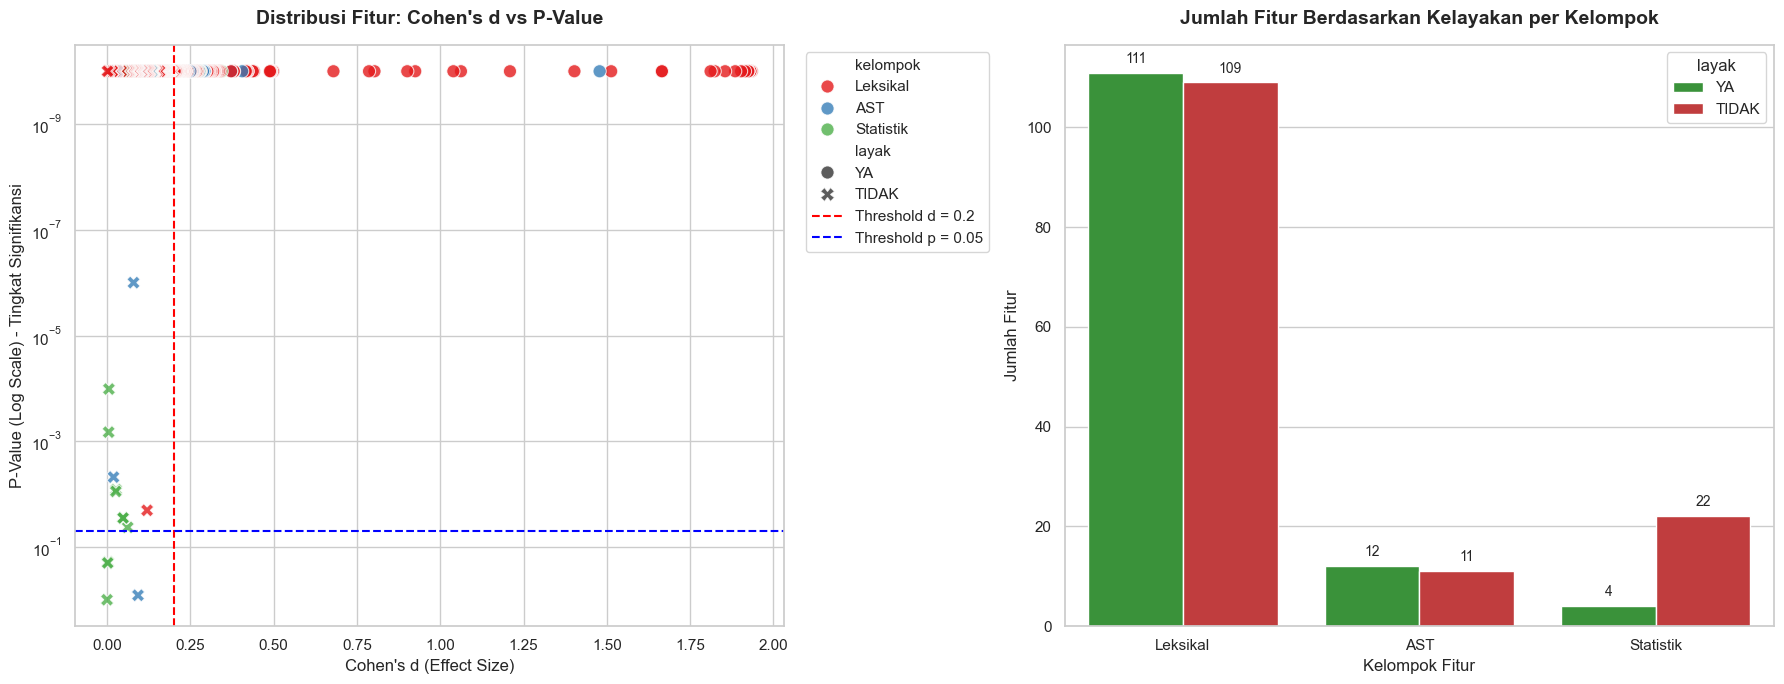

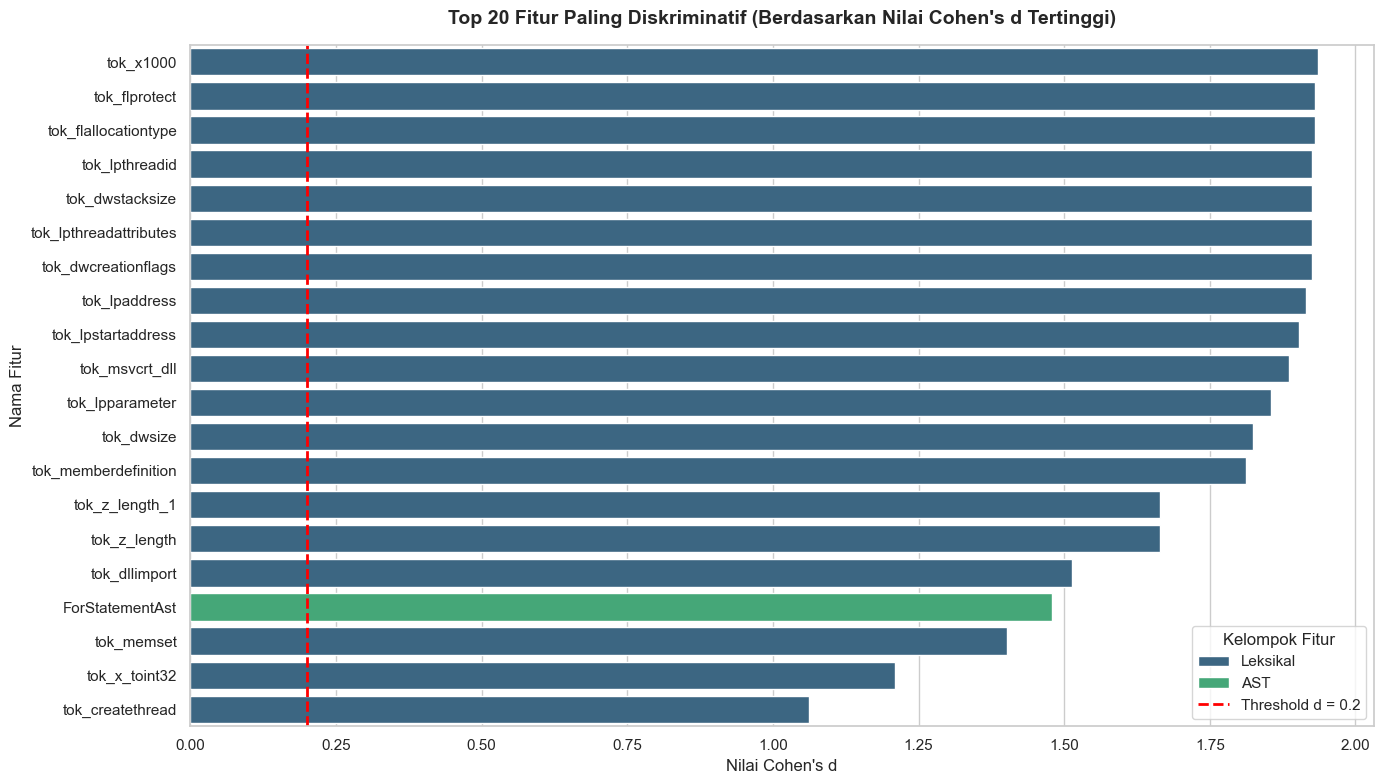

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# =====================================================================
# CELL 5 — VISUALISASI HASIL SELEKSI FITUR (COHEN'S D & P-VALUE)
# =====================================================================
print("="*80)
print("CELL 5 — VISUALISASI HASIL SELEKSI FITUR")
print("="*80)

output_dir = Path("hasil_ekstraksi")
seleksi_file = output_dir / "seleksi_semua_fitur.csv"

if not seleksi_file.exists():
    raise FileNotFoundError(f"File {seleksi_file.name} tidak ditemukan. Pastikan Cell 3 sudah dijalankan.")

df_seleksi = pd.read_csv(seleksi_file)

# Konfigurasi style seaborn
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 7))

# ---------------------------------------------------------------------
# GRAFIK 1: Scatter Plot (Cohen's d vs P-Value)
# ---------------------------------------------------------------------
plt.subplot(1, 2, 1)

# Tambahkan nilai minimal p-value agar tidak menabrak error log(0)
p_val_plot = df_seleksi['p_value'].apply(lambda x: max(x, 1e-10))

sns.scatterplot(data=df_seleksi, x='cohens_d', y=p_val_plot, hue='kelompok', 
                style='layak', palette='Set1', s=90, alpha=0.8)

# Garis ambang batas (Threshold)
plt.axvline(x=0.2, color='red', linestyle='--', label="Threshold d = 0.2")
plt.axhline(y=0.05, color='blue', linestyle='--', label="Threshold p = 0.05")

# Invert & Log-scale y-axis agar p-value yang paling signifikan (mendekati 0) berada di atas
plt.yscale('log')
plt.gca().invert_yaxis() 

plt.title("Distribusi Fitur: Cohen's d vs P-Value", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Cohen's d (Effect Size)", fontsize=12)
plt.ylabel("P-Value (Log Scale) - Tingkat Signifikansi", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# ---------------------------------------------------------------------
# GRAFIK 2: Komposisi Fitur Layak vs Tidak Layak
# ---------------------------------------------------------------------
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df_seleksi, x='kelompok', hue='layak', palette={'YA': '#2ca02c', 'TIDAK': '#d62728'})

plt.title("Jumlah Fitur Berdasarkan Kelayakan per Kelompok", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Kelompok Fitur", fontsize=12)
plt.ylabel("Jumlah Fitur", fontsize=12)

# Tambahkan label angka di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# GRAFIK 3: Top 20 Fitur Paling Diskriminatif (Horizontal Bar Chart)
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 8))
top20 = df_seleksi.head(20)

sns.barplot(data=top20, x='cohens_d', y='fitur', hue='kelompok', dodge=False, palette='viridis')

plt.axvline(x=0.2, color='red', linestyle='--', linewidth=2, label="Threshold d = 0.2")
plt.title("Top 20 Fitur Paling Diskriminatif (Berdasarkan Nilai Cohen's d Tertinggi)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Nilai Cohen's d", fontsize=12)
plt.ylabel("Nama Fitur", fontsize=12)
plt.legend(title="Kelompok Fitur", loc='lower right')

plt.tight_layout()
plt.show()